# Mamba selective-scan (S6) kernel — Colab T4 runner

End-to-end on a **free-tier T4 (Turing sm_75, 16GB)**:
1. Assert the GPU is a T4 and print VRAM.
2. Install requirements.
3. JIT-compile the CUDA extension (sm_75).
4. Run the full pytest suite (forward allclose, **float64 gradcheck**, edge cases) — now including the real Triton + CUDA kernels.
5. Run the honest benchmarks (linear-memory scan vs quadratic attention; latency).
6. Show the two figures inline.

This project is correctness-first: the backward math is float64-gradcheck-verified, and the kernels port those verified formulas.

## 0. Get the code
If running in Colab, clone your repo (replace the URL). If you uploaded the folder, `cd` into it instead.

In [1]:
import os
REPO_URL = 'https://github.com/HamzaImtiaz03/mamba-selective-scan.git'
if not os.path.exists('mamba_scan'):
    if os.path.exists('mamba-selective-scan'):
        %cd mamba-selective-scan
    else:
        !git clone $REPO_URL
        %cd mamba-selective-scan
print('cwd:', os.getcwd())
assert os.path.exists('mamba_scan'), 'run from the repo root (the folder containing mamba_scan/)'

/content/mamba-selective-scan
cwd: /content/mamba-selective-scan


## 1. Assert T4 + print VRAM

In [2]:
import torch
assert torch.cuda.is_available(), 'No CUDA. In Colab: Runtime > Change runtime type > T4 GPU.'
p = torch.cuda.get_device_properties(0)
print(f'GPU: {p.name} | capability sm_{p.major}{p.minor} | VRAM {p.total_memory/1e9:.1f} GB')
print(f'torch {torch.__version__}')
if 'T4' not in p.name:
    print('WARNING: expected a T4 (sm_75). The kernels are tuned/compiled for sm_75.')
assert p.major == 7 and p.minor == 5, 'kernels are built with -gencode arch=compute_75,code=sm_75'

GPU: Tesla T4 | capability sm_75 | VRAM 15.6 GB
torch 2.11.0+cu128


## 2. Install requirements
Triton ships with the Colab CUDA torch wheel.

In [3]:
!pip install -q numpy einops pytest matplotlib
import triton; print('triton', triton.__version__)

triton 3.6.0


## 3. JIT-compile the CUDA extension (sm_75)
First call triggers nvcc; subsequent calls hit the build cache.

In [4]:
!pip install -q ninja

In [5]:
import time
from mamba_scan.cuda_scan import _load_extension
t0 = time.time(); ext = _load_extension(); print(f'compiled in {time.time()-t0:.1f}s -> {ext}')

compiled in 138.5s -> <module 'selective_scan_cuda_ext' from '/root/.cache/torch_extensions/py312_cu128/selective_scan_cuda_ext/selective_scan_cuda_ext.so'>


## 4. Full test suite (now exercises the real Triton + CUDA kernels)
The GPU-gated tests that were skipped on CPU now run: Triton & CUDA forward allclose, gradcheck, fp16, edge cases.

In [6]:
!python -m pytest tests/ -q

........................................................................ [ 77%]
................F.F.F                                                    [100%]
=================================== FAILURES ===================================
____________ test_forward_fp32_cuda[True-cuda-selective_scan_cuda] _____________

name = 'cuda', impl = <function selective_scan_cuda at 0x7837b3d50540>
with_dskip = True

    @pytest.mark.skipif(not HAS_CUDA, reason="needs CUDA (Colab T4)")
    @pytest.mark.parametrize("name,impl", _cuda_impls())
    @pytest.mark.parametrize("with_dskip", [True, False])
    def test_forward_fp32_cuda(name, impl, with_dskip):
        t = make_inputs(2, 128, 32, 16, dtype=torch.float32, with_dskip=with_dskip,
                        device="cuda", seed=11)
        y_ref = selective_scan_ref(t["x"], t["delta"], t["A"], t["B_mat"], t["C_mat"], t["D_skip"])
        y = impl(t["x"], t["delta"], t["A"], t["B_mat"], t["C_mat"], t["D_skip"])
>       assert torch.allclose(y_

## 4b. Quick direct check: CUDA & Triton vs reference (forward + grads)

In [7]:
import torch, torch.nn.functional as F
from mamba_scan.reference import selective_scan_ref
from mamba_scan.backward_math import selective_scan_ref_autograd
from mamba_scan.triton_scan import selective_scan_triton
from mamba_scan.cuda_scan import selective_scan_cuda

def mk(B,L,D,N,dev='cuda',dt=torch.float32):
    x=torch.randn(B,L,D,device=dev,dtype=dt); delta=F.softplus(torch.randn(B,L,D,device=dev,dtype=dt))
    A=-torch.exp(torch.randn(D,N,device=dev,dtype=dt)); Bm=torch.randn(B,L,N,device=dev,dtype=dt)
    Cm=torch.randn(B,L,N,device=dev,dtype=dt); Ds=torch.randn(D,device=dev,dtype=dt)
    return x,delta,A,Bm,Cm,Ds

ins = mk(2,256,32,16)
y_ref = selective_scan_ref(*ins)
for name, fn in [('triton', selective_scan_triton), ('cuda', selective_scan_cuda)]:
    y = fn(*ins)
    print(f'{name:7s} forward max_err = {(y-y_ref).abs().max().item():.2e}')

# grad check vs analytical reference grads
names=['x','delta','A','B','C','D']
for name, fn in [('triton', selective_scan_triton), ('cuda', selective_scan_cuda)]:
    a=[t.clone().requires_grad_(True) for t in ins]; b=[t.clone().requires_grad_(True) for t in ins]
    ya=fn(*a); g=torch.randn_like(ya); ya.backward(g)
    yb=selective_scan_ref_autograd(*b); yb.backward(g)
    errs=', '.join(f'{n}:{(a[i].grad-b[i].grad).abs().max().item():.1e}' for i,n in enumerate(names))
    print(f'{name:7s} grad errs  {errs}')

triton  forward max_err = 1.91e-05
cuda    forward max_err = 3.99e+01
triton  grad errs  x:1.9e-05, delta:2.3e-05, A:1.3e-03, B:2.2e-05, C:1.4e-05, D:1.6e-05
cuda    grad errs  x:1.7e-05, delta:3.0e+01, A:8.2e+02, B:2.3e-05, C:3.6e+01, D:1.5e-05


## 5. Benchmarks — memory (linear vs quadratic) and latency

In [8]:
!python benchmarks/bench_memory.py --d_model 256
!python benchmarks/bench_latency.py --d_inner 256 --d_state 16

device={'device': 'cuda', 'name': 'Tesla T4', 'total_mem_gb': 15.64, 'capability': 'sm_75'}  backend=triton  dtype=torch.float16  d_model=256
       L |    scan (MB) |   attention (MB)
--------------------------------------------
    1024 |         50.0 |             64.1
    4096 |        171.6 |            856.3
   16384 |        658.4 |          13464.4
   65536 |       2603.6 |              OOM
  100000 |       3971.8 |              OOM

saved -> /content/mamba-selective-scan/benchmarks/results/memory.json
[latency] official mamba-ssm not available: ModuleNotFoundError: No module named 'mamba_ssm'
device={'device': 'cuda', 'name': 'Tesla T4', 'total_mem_gb': 15.64, 'capability': 'sm_75'}  dtype=torch.float16  d_inner=256  d_state=16
    L |    reference |     parallel |       triton |         cuda
-----------------------------------------------------------------
ninja: no work to do.
  512 |       63.126 |        2.399 |        0.322 |        3.792
 1024 |      126.337 |        5.0

## 6. Plots inline

[plot] wrote /content/mamba-selective-scan/benchmarks/figures/memory_vs_length.png
[plot] wrote /content/mamba-selective-scan/benchmarks/figures/latency_vs_length.png


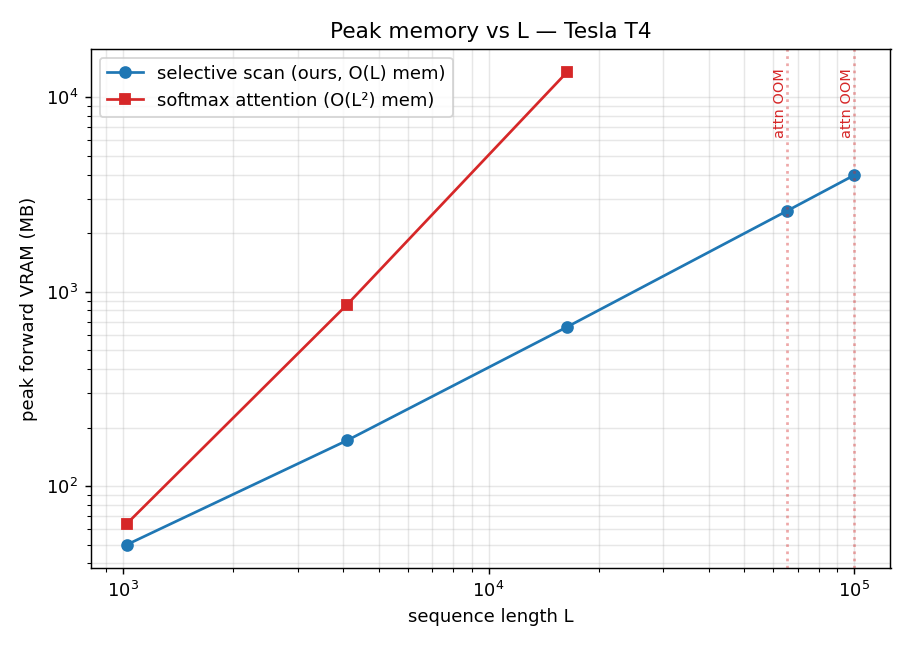

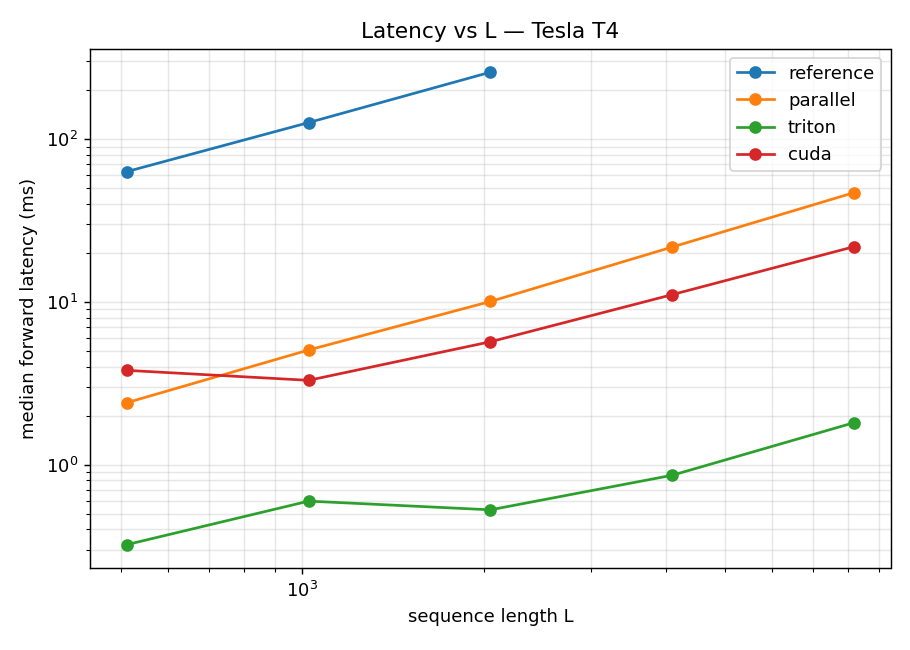

In [9]:
!python benchmarks/plot_results.py
from IPython.display import Image, display
display(Image('benchmarks/figures/memory_vs_length.png'))
display(Image('benchmarks/figures/latency_vs_length.png'))